In [2]:
#%pip install openpyxl wordcloud flair hdbscan==0.8.40 bertopic spacy numpy==1.26.4

In [1]:
import pandas as pd
import os
import platform
from wordcloud import WordCloud

In [2]:
platform.__version__

'1.0.8'

In [3]:
def is_running_on_azure():
    return "AML_CloudName" in os.environ

In [13]:
if is_running_on_azure() is True:
    from azure.ai.ml import MLClient
    from azure.identity import DefaultAzureCredential

    ml_client = MLClient.from_config(credential=DefaultAzureCredential())
    data_asset = ml_client.data.get("fnopi", version="1")

    #df_prestazioni_inf = pd.read_excel(data_asset.path+"Macroprestazioni_infermieristiche.xlsx")
    #df_prestazioni_inf_con_descrizione_mdn = pd.read_excel(data_asset.path+"df_prestazioni_inf_con_descrizione+mdn.xlsx")
    df_prestazioni_inf = pd.read_csv(data_asset.path+"Macroprestazioni_infermieristiche.csv", sep=';',encoding='latin-1')
    df_prestazioni_inf_con_descrizione_mdn = pd.read_csv(data_asset.path+"df_prestazioni_inf_con_descrizione+mdn.csv", sep=';',encoding='latin-1')

else:
    #df_prestazioni_inf = pd.read_excel("dataset/Macroprestazioni_infermieristiche.xlsx")
    #df_prestazioni_inf_con_descrizione_mdn = pd.read_excel("dataset/df_prestazioni_inf_con_descrizione+mdn.xlsx")
    df_prestazioni_inf = pd.read_csv("dataset/Macroprestazioni_infermieristiche.csv", sep=';',encoding='latin-1')
    df_prestazioni_inf_con_descrizione_mdn = pd.read_csv("dataset/df_prestazioni_inf_con_descrizione+mdn.csv", sep=';',encoding='latin-1')


Found the config file in: /config.json
Overriding of current TracerProvider is not allowed
Overriding of current LoggerProvider is not allowed
Overriding of current MeterProvider is not allowed
Attempting to instrument while already instrumented
Attempting to instrument while already instrumented
Attempting to instrument while already instrumented
Attempting to instrument while already instrumented
Attempting to instrument while already instrumented


In [14]:
df_prestazioni_inf.columns

Index(['Macroprestazione', 'Note infermieristiche',
       'Prestazione da nomenclatore', 'Unnamed: 3', 'Unnamed: 4',
       'Unnamed: 5'],
      dtype='object')

In [15]:
df_prestazioni_inf = df_prestazioni_inf[['Macroprestazione', 'Note infermieristiche',
       'Prestazione da nomenclatore']].copy()

In [16]:
df_prestazioni_inf.rename(columns={"Macroprestazione": "macroprestazione", "Note infermieristiche": "testo", "Prestazione da nomenclatore": "cod_valoremedio_liquidazione"}, inplace=True)

In [17]:
df_prestazioni_inf.head(10)

,macroprestazione,testo,cod_valoremedio_liquidazione
0,"Accesso Vascolare, Terapia Infusiva, Prelievo ...",Prelievi ematici,033t
1,"Accesso Vascolare, Terapia Infusiva, Prelievo ...",Prelievi venosi,033t
2,"Accesso Vascolare, Terapia Infusiva, Prelievo ...",Prelievi,033t
3,Medicazioni Avanzate,Medicazioni varie,031t
4,procedure clinico assistenziali,Clistere /svuotamento manuale,080t
5,"Accesso Vascolare, Terapia Infusiva, Prelievo ...",Prelievi ematici,033t
6,Medicazioni Avanzate,Medicazioni,031t
7,Medicazioni Avanzate,Medicazioni,031t
8,Educazione Sanitaria,Educazione al caregiver,122r
9,Medicazioni Avanzate,Medicazioni,031t


In [18]:
print("Numero di prestazioni sanitarie: " + str(len(df_prestazioni_inf)))

Numero di prestazioni sanitarie: 39490


In [19]:
df_prestazioni_inf.dropna(inplace=True)
df_prestazioni_inf.reset_index(inplace=True)
print("Numero di prestazioni sanitarie dopo cleaning di righe vuote: " + str(len(df_prestazioni_inf)))

Numero di prestazioni sanitarie dopo cleaning di righe vuote: 22614


### Cleaning dei testi

In [20]:
import re
import spacy
from spacy.cli.download import download

download('it_core_news_lg') # italian

/anaconda/envs/azureml_py310_sdkv2/lib/python3.10/site-packages/torch/cuda/__init__.py:789: UserWarning: Can't initialize NVML
  warnings.warn("Can't initialize NVML")


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 567.9/567.9 MB 26.9 MB/s eta 0:00:0000:0100:01
✔ Download and installation successful
You can now load the package via spacy.load('it_core_news_lg')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [21]:
it_nlp = spacy.load("it_core_news_lg")
stopwords = list(it_nlp.Defaults.stop_words)

In [22]:
def apply_text_cleaning(text):
    
    # 2. Normalize curly quotes and dashes and slash with blank
    text = text.replace("’", "'").replace("‘", "'") \
               .replace("“", '"').replace("”", '"') \
               .replace("–", "-").replace("—", "-") \
               .replace("/", " ").replace("-"," ") \
               .replace("\\", " ").replace(".."," ")

    # Optional: normalize Unicode characters to ASCII (e.g., é → e)
    # text = unicodedata.normalize("NFKD", text).encode("ascii", "ignore").decode("utf-8")    

    # 4. Lowercase
    text = text.lower()

    # 5. Remove punctuation (keep straight apostrophes and dashes)
    text = re.sub(r"[^\w\s]", ' ', text)

    # 6. Remove digits
    text = re.sub(r'\d+', '', text)

    return text
    # 7. Tokenize and remove stopwords: le rimuovo durante l'applicazione di BERTopic
   # sentences = italian_tokenizer.tokenize(text)
   # tokens = [word for sent in sentences for word in sent.split()]
   # tokens = [word for word in tokens if word not in stopwords]

   #return ' '.join(tokens)

In [23]:
df_prestazioni_inf['testo_pulito'] = [apply_text_cleaning(x) for x in df_prestazioni_inf["testo"]]

In [29]:
df_prestazioni_inf.iloc[1425]

index                                                                        1609
macroprestazione                                             Educazione Sanitaria
testo                           supporto relazionale all'utente, famiglia, car...
cod_valoremedio_liquidazione                                                 122r
testo_pulito                    supporto relazionale all utente  famiglia  car...
Name: 1425, dtype: object

In [30]:
df_prestazioni_inf['cod_valoremedio_liquidazione'] = [x.upper() for x in df_prestazioni_inf['cod_valoremedio_liquidazione']]

In [31]:
df_prestazioni_inf.iloc[200:280]

,index,macroprestazione,testo,cod_valoremedio_liquidazione,testo_pulito
200,204,Monitoraggi e Misurazioni,Monitoraggio parametri clinici,004T,monitoraggio parametri clinici
201,205,"Accesso Vascolare, Terapia Infusiva, Prelievo ...",Prelievo,033T,prelievo
202,206,"Accesso Vascolare, Terapia Infusiva, Prelievo ...",Prelievi,033T,prelievi
203,207,Monitoraggi e Misurazioni,Monitoraggio parametri vitali,004T,monitoraggio parametri vitali
204,208,"Accesso Vascolare, Terapia Infusiva, Prelievo ...",Prelievo,033T,prelievo
...,...,...,...,...,...
275,284,"Accesso Vascolare, Terapia Infusiva, Prelievo ...",Prelievi ematici,033T,prelievi ematici
276,285,"Accesso Vascolare, Terapia Infusiva, Prelievo ...",Prelievi ematici,033T,prelievi ematici
277,286,"Accesso Vascolare, Terapia Infusiva, Prelievo ...",Prelievo ematico/INR,033T,prelievo ematico inr
278,287,"Accesso Vascolare, Terapia Infusiva, Prelievo ...",Prelievi ematici,033T,prelievi ematici


### Note ricodificate post correzione

In [32]:
df_prestazioni_inf_con_descrizione_mdn.columns

Index(['index', 'macroprestazione', 'testo', 'testo_pulito',
       'cod_valoremedio_liquidazione', 'descr_cod_valoremedio_liquidazione',
       'cod_modificato'],
      dtype='object')

In [33]:
df_prestazioni_inf_con_descrizione_mdn.head()

,index,macroprestazione,testo,testo_pulito,cod_valoremedio_liquidazione,descr_cod_valoremedio_liquidazione,cod_modificato
0,1459,Educazione Sanitaria,"colloquio famigliare, singole, educativi, info...",colloquio famigliare singole educativi informa...,122T,NaN,122R
1,2504,Educazione Sanitaria,Colloquio infermieristico,colloquio infermieristico,122T,NaN,122R
2,2525,Educazione Sanitaria,colloquio confamiliari,colloquio confamiliari,122T,NaN,122R
3,2627,"PAI, pianificazione, valutazione",Interventi di supporto,interventi di supporto,122T,NaN,122R
4,2877,"PAI, pianificazione, valutazione",analisi dei bisogni,analisi dei bisogni,122T,NaN,122R


In [34]:
del df_prestazioni_inf_con_descrizione_mdn['cod_valoremedio_liquidazione']

In [35]:
del df_prestazioni_inf_con_descrizione_mdn['descr_cod_valoremedio_liquidazione']

In [36]:
df_prestazioni_inf_con_descrizione_mdn.rename({'cod_modificato':'cod_valoremedio_liquidazione'},axis=1, inplace=True)

In [37]:
df_prestazioni_inf_con_descrizione_mdn.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 277 entries, 0 to 276
Data columns (total 5 columns):
 #   Column                        Non-Null Count  Dtype 
---  ------                        --------------  ----- 
 0   index                         277 non-null    int64 
 1   macroprestazione              277 non-null    object
 2   testo                         277 non-null    object
 3   testo_pulito                  276 non-null    object
 4   cod_valoremedio_liquidazione  276 non-null    object
dtypes: int64(1), object(4)
memory usage: 10.9+ KB


In [38]:
df_prestazioni_inf_con_descrizione_mdn['cod_valoremedio_liquidazione'] = df_prestazioni_inf_con_descrizione_mdn['cod_valoremedio_liquidazione'].astype(str)

In [39]:
df_prestazioni_inf_con_descrizione_mdn['cod_valoremedio_liquidazione'] = [x.upper() for x in df_prestazioni_inf_con_descrizione_mdn['cod_valoremedio_liquidazione']]

In [40]:
df_prestazioni_inf_con_descrizione_mdn['cod_valoremedio_liquidazione'] = df_prestazioni_inf_con_descrizione_mdn['cod_valoremedio_liquidazione'].str.replace(' ', '', regex=False)

In [41]:
df_prestazioni_inf_con_descrizione_mdn

,index,macroprestazione,testo,testo_pulito,cod_valoremedio_liquidazione
0,1459,Educazione Sanitaria,"colloquio famigliare, singole, educativi, info...",colloquio famigliare singole educativi informa...,122R
1,2504,Educazione Sanitaria,Colloquio infermieristico,colloquio infermieristico,122R
2,2525,Educazione Sanitaria,colloquio confamiliari,colloquio confamiliari,122R
3,2627,"PAI, pianificazione, valutazione",Interventi di supporto,interventi di supporto,122R
4,2877,"PAI, pianificazione, valutazione",analisi dei bisogni,analisi dei bisogni,122R
...,...,...,...,...,...
272,38498,procedure clinico assistenziali,Mobilizzazione e igiene,mobilizzazione e igiene,109T
273,38522,procedure clinico assistenziali,igiene e mobilizzazione,igiene e mobilizzazione,109T
274,38708,"Accesso Vascolare, Terapia Infusiva, Prelievo ...",Gestione dispositivi vascolari,gestione dispositivi vascolari,020T
275,39322,procedure clinico assistenziali,Assistenza di base/cura della persona,assistenza di basecura della persona,109T


In [42]:
len(df_prestazioni_inf_con_descrizione_mdn)

277

In [43]:
tmp = df_prestazioni_inf_con_descrizione_mdn.dropna()

In [44]:
len(tmp)

276

In [45]:
righe_con_na = df_prestazioni_inf_con_descrizione_mdn[df_prestazioni_inf_con_descrizione_mdn.isna().any(axis=1)]
righe_con_na

,index,macroprestazione,testo,testo_pulito,cod_valoremedio_liquidazione
256,37083,procedure clinico assistenziali,"EinlÃ¤ufe,DrainspÃ¼lungen",NaN,NAN


In [46]:
df_prestazioni_inf_con_descrizione_mdn.dropna(inplace=True)
len(df_prestazioni_inf_con_descrizione_mdn)

276

Sostituisco il codice delle prestazioni ripulite nelle precedenti

In [47]:
len(df_prestazioni_inf)

22614

In [48]:
df_prestazioni_inf[df_prestazioni_inf['index']==1459]

,index,macroprestazione,testo,cod_valoremedio_liquidazione,testo_pulito
1284,1459,Educazione Sanitaria,"colloquio famigliare, singole, educativi, info...",122T,colloquio famigliare singole educativi info...


In [49]:
df_prestazioni_inf_con_descrizione_mdn[df_prestazioni_inf_con_descrizione_mdn['index']==1459]

,index,macroprestazione,testo,testo_pulito,cod_valoremedio_liquidazione
0,1459,Educazione Sanitaria,"colloquio famigliare, singole, educativi, info...",colloquio famigliare singole educativi informa...,122R


In [50]:
df_prestazioni_inf.set_index('index', inplace=True)
df_prestazioni_inf_con_descrizione_mdn.set_index('index', inplace=True)

df_prestazioni_inf['cod_valoremedio_liquidazione'].update(df_prestazioni_inf_con_descrizione_mdn['cod_valoremedio_liquidazione'])



In [51]:
df_prestazioni_inf.reset_index(inplace=True)  # Se vuoi ripristinare l'indice

In [52]:
df_prestazioni_inf_con_descrizione_mdn.reset_index(inplace=True)  # Se vuoi ripristinare l'indice

In [53]:
df_prestazioni_inf.iloc[4319]

index                                                                        4728
macroprestazione                                             Medicazioni Avanzate
testo                           medicazioni/bendaggi lesioni vascolari/diabetiche
cod_valoremedio_liquidazione                                                 031T
testo_pulito                    medicazioni bendaggi lesioni vascolari diabetiche
Name: 4319, dtype: object

### Analisi Esplorativa

In [54]:
df_prestazioni_inf.groupby('cod_valoremedio_liquidazione').count()[['testo']].rename(columns={'testo': 'count'}).sort_values(by='count', ascending=False).to_csv("csv/N_prestazioni_by_cod_valoremedio_liquidazione_update.csv", sep=';')

In [55]:
df_prestazioni_inf.groupby('macroprestazione').count()[['testo']].rename(columns={'testo': 'count'}).sort_values(by='count', ascending=False).to_csv("csv/N_prestazioni_by_macroprestazione_update.csv", sep=';')

In [56]:
df_prestazioni_inf.groupby('testo_pulito').count()[['macroprestazione']].rename(columns={'macroprestazione': 'count'}).sort_values(by='count', ascending=False).to_csv("csv/N_prestazioni_by_note_infermieristiche_update.csv", sep=';')

Link descrizione testuale del "cod_valoremedio_liquidazione"

In [57]:
df_codes_valmedio_liq = pd.read_csv("classifications/Classificazione_da_decreto_valoremedioliquidazione.csv", sep='\t')

In [58]:
df_codes_valmedio_liq.rename(columns={'Codice':'cod_valoremedio_liquidazione'},inplace=True)

In [59]:
df_codes_valmedio_liq.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 192 entries, 0 to 191
Data columns (total 2 columns):
 #   Column                        Non-Null Count  Dtype 
---  ------                        --------------  ----- 
 0   cod_valoremedio_liquidazione  192 non-null    object
 1   ELENCO PRESTAZIONI            192 non-null    object
dtypes: object(2)
memory usage: 3.1+ KB


In [60]:
df_codes_valmedio_liq['cod_valoremedio_liquidazione'] = df_codes_valmedio_liq['cod_valoremedio_liquidazione'].str.replace('O', '0', regex=False)

In [61]:
df_codes_valmedio_liq.to_csv("classifications/Classificazione_da_decreto_valoremedioliquidazione_corretto.csv", sep='\t')

In [62]:
df_prestazioni_inf.columns

Index(['index', 'macroprestazione', 'testo', 'cod_valoremedio_liquidazione',
       'testo_pulito'],
      dtype='object')

In [63]:
df_prestazioni_inf = df_prestazioni_inf[['index','macroprestazione','testo','testo_pulito','cod_valoremedio_liquidazione']]

In [64]:
df_merge = df_prestazioni_inf.merge(df_codes_valmedio_liq, how='left', on='cod_valoremedio_liquidazione')


In [65]:
len(df_prestazioni_inf)

22614

In [66]:
len(df_merge)

22614

In [67]:
nan_rows = df_merge.isnull().any(axis=0)
print(nan_rows)

index                           False
macroprestazione                False
testo                           False
testo_pulito                    False
cod_valoremedio_liquidazione    False
ELENCO PRESTAZIONI              False
dtype: bool


In [68]:
df_merge.rename(columns={'ELENCO PRESTAZIONI': 'descr_cod_valoremedio_liquidazione'},inplace=True)
df_merge.columns

Index(['index', 'macroprestazione', 'testo', 'testo_pulito',
       'cod_valoremedio_liquidazione', 'descr_cod_valoremedio_liquidazione'],
      dtype='object')

In [69]:
df_merge_righe_con_na = df_merge[df_merge.isna().any(axis=1)]
df_merge_righe_con_na

,index,macroprestazione,testo,testo_pulito,cod_valoremedio_liquidazione,descr_cod_valoremedio_liquidazione


In [70]:
df_merge.head(5)

,index,macroprestazione,testo,testo_pulito,cod_valoremedio_liquidazione,descr_cod_valoremedio_liquidazione
0,0,"Accesso Vascolare, Terapia Infusiva, Prelievo ...",Prelievi ematici,prelievi ematici,033T,Prelievo capillare e venoso del sangue o racco...
1,1,"Accesso Vascolare, Terapia Infusiva, Prelievo ...",Prelievi venosi,prelievi venosi,033T,Prelievo capillare e venoso del sangue o racco...
2,2,"Accesso Vascolare, Terapia Infusiva, Prelievo ...",Prelievi,prelievi,033T,Prelievo capillare e venoso del sangue o racco...
3,3,Medicazioni Avanzate,Medicazioni varie,medicazioni varie,031T,Medicazione semplice
4,4,procedure clinico assistenziali,Clistere /svuotamento manuale,clistere svuotamento manuale,080T,Preparazione ed effettuazione di clistere


In [71]:
#df_merge[df_merge['descr_cod_valoremedio_liquidazione'].isnull()==True].to_csv("df_prestazioni_inf_con_descrizione_codvaloremedio_liquidazione_null_update.csv",sep='\t',index=False)

Salva dataset completo della descrizione della classificazione e del codice pulito

In [72]:
df_merge

,index,macroprestazione,testo,testo_pulito,cod_valoremedio_liquidazione,descr_cod_valoremedio_liquidazione
0,0,"Accesso Vascolare, Terapia Infusiva, Prelievo ...",Prelievi ematici,prelievi ematici,033T,Prelievo capillare e venoso del sangue o racco...
1,1,"Accesso Vascolare, Terapia Infusiva, Prelievo ...",Prelievi venosi,prelievi venosi,033T,Prelievo capillare e venoso del sangue o racco...
2,2,"Accesso Vascolare, Terapia Infusiva, Prelievo ...",Prelievi,prelievi,033T,Prelievo capillare e venoso del sangue o racco...
3,3,Medicazioni Avanzate,Medicazioni varie,medicazioni varie,031T,Medicazione semplice
4,4,procedure clinico assistenziali,Clistere /svuotamento manuale,clistere svuotamento manuale,080T,Preparazione ed effettuazione di clistere
...,...,...,...,...,...,...
22609,39482,"Accesso Vascolare, Terapia Infusiva, Prelievo ...",SOMMINISTRAZIONE TERAPIA ENDOVENOSA/INTRAMUSCO...,somministrazione terapia endovenosa intramusco...,015T,Somministrazione dei medicinali prescritti per...
22610,39483,Educazione Sanitaria,Addestramento del caregivers per la necessità ...,addestramento del caregivers per la necessità ...,122R,Accoglienza del paziente: presentazione di luo...
22611,39485,Educazione Sanitaria,Educazione e gestione pazienti con PEG,educazione e gestione pazienti con peg,055T,Preparazione e somministrazione di alimenti sp...
22612,39486,procedure clinico assistenziali,Sostituzione catetere vescicale,sostituzione catetere vescicale,065T,Assistenza ordinaria ad un paziente portatore ...


In [73]:
df_merge.to_csv("csv/df_prestazioni_inf_clean_update.csv",sep='\t',index=False)

### Regole deterministiche per ulteriore pulizia dei testi delle note

In [74]:
from sklearn.feature_extraction.text import CountVectorizer

vectorizer = CountVectorizer(stop_words=stopwords)
X = vectorizer.fit_transform(df_merge['testo_pulito'])
vocab = vectorizer.get_feature_names_out()
print(list(vocab))

/anaconda/envs/azureml_py310_sdkv2/lib/python3.10/site-packages/sklearn/feature_extraction/text.py:402: UserWarning: Your stop_words may be inconsistent with your preprocessing. Tokenizing the stop words generated tokens ['gl', 'nient'] not in stop_words.
  warnings.warn(


In [75]:
len(vocab)

2489

In [76]:
with open('vocabulary/vocab_FNOPI.txt', 'w') as f:
    for line in vocab:
        f.write("%s\n" % line)

In [77]:
df_vocab = pd.DataFrame(vocab)
df_vocab.columns = ['word']

In [78]:
df_vocab

,word
0,aa
1,aaii
2,ab
3,abilita
4,abilità
...,...
2484,zinco
2485,zione
2486,zu
2487,zusammenarbeit


In [79]:
df_vocab.to_excel("vocabulary/vocab_FNOPI.xlsx", index=False)

### Wordcloud dei testi

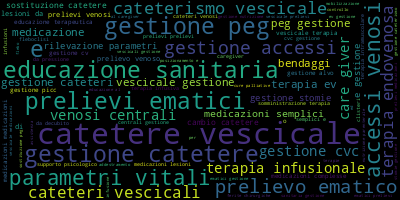

In [80]:
full_text = ','.join(list(df_prestazioni_inf["testo_pulito"].values))
wordcloud = WordCloud(background_color="black",
                        max_words=100,
                        contour_width=2,
                        contour_color='yellow')

wordcloud.generate(full_text)
wordcloud.to_image()